# SOLUTIONS: Probability Distributions for Business Stats
**CTP Data Science — Week 05**

Solutions for the exercises in `Business-Stats-Distributions.ipynb`.
This notebook is self-contained: it re-creates any data it needs, so exact numbers may differ slightly from the lecture notebook. The *conclusions* should match.

> Try the exercises yourself first! Reading a solution is not the same as being able to write one.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def show(samples, title, discrete=False, bins=40):
    fig, ax = plt.subplots()
    if discrete:
        vals, counts = np.unique(samples, return_counts=True)
        ax.bar(vals, counts / len(samples), color="steelblue", alpha=0.8)
        ax.set_ylabel("probability")
    else:
        ax.hist(samples, bins=bins, density=True, color="steelblue", alpha=0.8)
        ax.set_ylabel("density")
    mean, median = np.mean(samples), np.median(samples)
    ax.axvline(mean, color="crimson", lw=2, label=f"mean = {mean:,.2f}")
    ax.axvline(median, color="orange", lw=2, ls="--", label=f"median = {median:,.2f}")
    ax.set_title(title); ax.legend(); plt.show()

---
# 🟢 Beginner Solutions

### B1. Cafe customers per hour
Customers arriving independently at a steady average rate, counted per time window → **Poisson** with λ = 30.

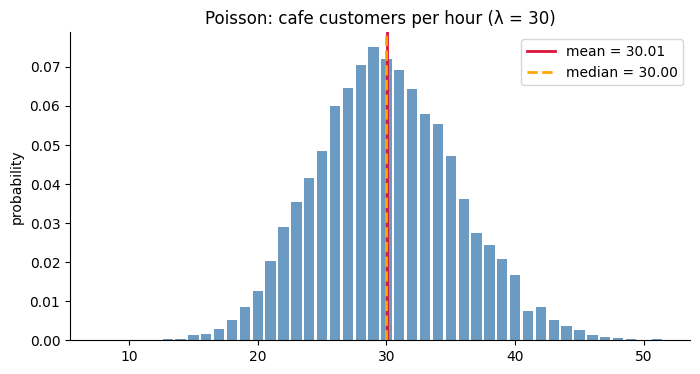

mean = 30.01, variance = 30.08  (Poisson: these should be ~equal)


In [2]:
cafe = rng.poisson(lam=30, size=10_000)
show(cafe, "Poisson: cafe customers per hour (λ = 30)", discrete=True)
print(f"mean = {cafe.mean():.2f}, variance = {cafe.var():.2f}  (Poisson: these should be ~equal)")

Note that with a large λ the Poisson already looks pretty bell-shaped. For big λ it's well approximated by a Normal(λ, √λ).

### B2. Salaries

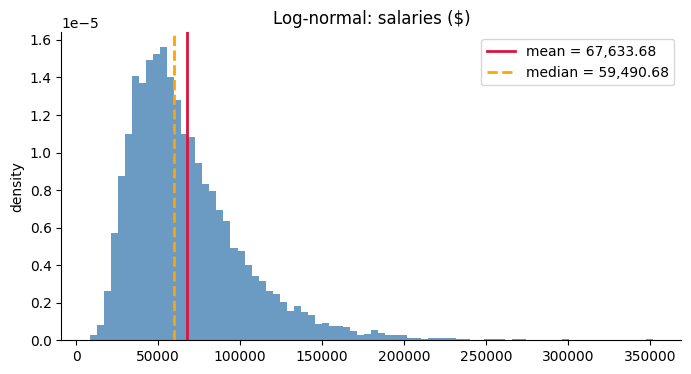

Mean:   $67,634
Median: $59,491


In [3]:
salaries = rng.lognormal(mean=11, sigma=0.5, size=10_000)
show(salaries, "Log-normal: salaries ($)", bins=80)
print(f"Mean:   ${salaries.mean():,.0f}")
print(f"Median: ${np.median(salaries):,.0f}")

**Report the median in a job posting.** The mean is pulled up by a few very high earners, so it overstates what a typical person in the role makes.
The median is the salary of the person in the middle: half earn less, half earn more.
(For a log-normal, median = e^μ = e^11 ≈ $59,900, and mean = e^(μ + σ²/2) ≈ $67,900.)

### B3. Why mean = median for the normal but not the log-normal
The normal distribution is **symmetric**: values above and below the center balance out exactly, so the balance point (mean) and the middle value (median) are the same.

The log-normal is **right-skewed**: it can't go below 0 but has a long tail of large values. The median only cares about *order*, so a $1,000,000 salary counts the same as a $70,000 one (both are "above the middle"). The mean cares about *size*, so that one huge value drags it upward.

---
# 🟡 Intermediate Solutions

### I1. Website crashes (Poisson, λ = 3 per week)

In [4]:
crashes = stats.poisson(mu=3)
print(f"P(0 crashes)         = {crashes.pmf(0):.4f}")
print(f"P(6 or more crashes) = {crashes.sf(5):.4f}")

P(0 crashes)         = 0.0498
P(6 or more crashes) = 0.0839


⚠️ Common mistake: `sf(6)` gives P(X **> 6**), i.e. 7 or more. For "6 or more" on a discrete distribution you need `sf(5)`.
About 5% of weeks have zero crashes and about 8% have 6+.

### I2. Call center hold times (Exponential, mean 4 min)

In [5]:
hold = stats.expon(scale=4)
print(f"P(wait > 10 min)       = {hold.sf(10):.3f}")
print(f"90th percentile wait   = {hold.ppf(0.90):.2f} min")

P(wait > 10 min)       = 0.082
90th percentile wait   = 9.21 min


About 8% of callers wait over 10 minutes, and 1 in 10 callers waits more than ~9.2 minutes even though the *average* is only 4.

### I3. Email campaign (Binomial, n = 2000, p = 0.22)

In [6]:
opens = stats.binom(n=2000, p=0.22)
print(f"Expected opens: {opens.mean():.0f}  (sd ≈ {opens.std():.1f})")
print(f"P(400 or fewer) = {opens.cdf(400):.4f}")

Expected opens: 440  (sd ≈ 18.5)
P(400 or fewer) = 0.0157


We expected 440 opens and got 400, about 2.2 standard deviations low. P ≈ 0.016, so this would happen by chance only ~1.6% of the time.
**Yes, worth investigating**: subject line, send time, a spam-filter issue, or a stale email list.

### I4. Confidence interval with n = 25 vs n = 200

In [7]:
population = rng.lognormal(mean=3.5, sigma=0.9, size=100_000)

def t_ci(sample, conf=0.95):
    n = len(sample)
    return stats.t.interval(conf, df=n - 1, loc=sample.mean(), scale=stats.sem(sample))

for n in [25, 200]:
    s = rng.choice(population, size=n)
    lo, hi = t_ci(s)
    print(f"n = {n:>3}:  CI = ${lo:6.2f} to ${hi:6.2f}   width = ${hi - lo:.2f}")
print(f"True mean: ${population.mean():.2f}")

n =  25:  CI = $ 35.40 to $ 77.20   width = $41.79
n = 200:  CI = $ 42.09 to $ 61.51   width = $19.42
True mean: $49.70


The interval gets about **2× narrower** here. On average it should shrink by **√8 ≈ 2.8×**, since the standard error is σ/√n: 8× more data shrinks the uncertainty by √8, not by 8. (Any single sample is noisy, especially the n = 25 one, so your ratio will vary. Rerun the cell a few times.)
Business translation: to halve your margin of error you need **4× the data**. Precision gets expensive fast.

---
# 🔴 Advanced Solutions

### A1. Does Weibull win on equipment lifetimes?

In [8]:
lifetimes = rng.weibull(1.5, 3000) * 10

candidates = {
    "norm": stats.norm,
    "expon": stats.expon,
    "lognorm": stats.lognorm,
    "gamma": stats.gamma,
    "weibull_min": stats.weibull_min,
}

rows = []
for name, dist in candidates.items():
    params = dist.fit(lifetimes) if name == "norm" else dist.fit(lifetimes, floc=0)
    loglik = np.sum(dist.logpdf(lifetimes, *params))
    k = len(params) - (0 if name == "norm" else 1)
    rows.append({"dist": name, "AIC": 2 * k - 2 * loglik, "params": np.round(params, 3)})

pd.DataFrame(rows).sort_values("AIC")

,dist,AIC,params
4,weibull_min,18703.220820,"[1.489, 0.0, 10.235]"
3,gamma,18734.444550,"[1.906, 0.0, 4.849]"
2,lognorm,19214.534996,"[0.855, 0.0, 6.955]"
1,expon,19346.442900,"[0.0, 9.245]"
0,norm,19592.909492,"[9.245, 6.334]"


**Yes, Weibull wins**, and its fitted shape parameter (~1.5) and scale (~10) recover the values we used to generate the data.
Gamma is usually a close second; they can look similar. Weibull is the standard choice for time-to-failure because its shape parameter has a meaning: shape > 1 means things wear out (failure risk rises with age), shape < 1 means early failures dominate.

### A2. Sample size for P(B better) > 99% on average
True rates: A = 8.0%, B = 9.2%. For each sample size we simulate many experiments and average the Bayesian P(B > A).
We use a normal approximation to each Beta posterior to keep it fast.

n per group =  1,000:  average P(B better) = 0.751 
n per group =  2,000:  average P(B better) = 0.826 
n per group =  4,000:  average P(B better) = 0.913 
n per group =  8,000:  average P(B better) = 0.972 
n per group = 12,000:  average P(B better) = 0.990 ✅
n per group = 16,000:  average P(B better) = 0.996 ✅
n per group = 20,000:  average P(B better) = 0.999 ✅
n per group = 30,000:  average P(B better) = 1.000 ✅


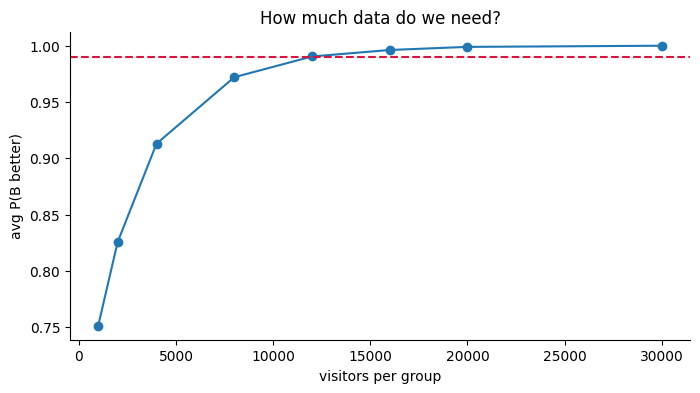

In [9]:
def p_b_better(conv_A, conv_B, n):
    a_A, b_A = 1 + conv_A, 1 + n - conv_A
    a_B, b_B = 1 + conv_B, 1 + n - conv_B
    mA, mB = a_A / (a_A + b_A), a_B / (a_B + b_B)
    vA = a_A * b_A / ((a_A + b_A) ** 2 * (a_A + b_A + 1))
    vB = a_B * b_B / ((a_B + b_B) ** 2 * (a_B + b_B + 1))
    return stats.norm.cdf((mB - mA) / np.sqrt(vA + vB))

sizes = [1_000, 2_000, 4_000, 8_000, 12_000, 16_000, 20_000, 30_000]
reps = 2_000
avg_prob = []
for n in sizes:
    cA = rng.binomial(n, 0.080, size=reps)
    cB = rng.binomial(n, 0.092, size=reps)
    avg_prob.append(p_b_better(cA, cB, n).mean())

for n, p in zip(sizes, avg_prob):
    print(f"n per group = {n:>6,}:  average P(B better) = {p:.3f} {'✅' if p > 0.99 else ''}")

plt.plot(sizes, avg_prob, "o-"); plt.axhline(0.99, color="crimson", ls="--")
plt.xlabel("visitors per group"); plt.ylabel("avg P(B better)"); plt.title("How much data do we need?"); plt.show()

You need **roughly 12,000 visitors per group**, about 3× what the lecture example used.
Small lifts (8.0% → 9.2%) need a lot of traffic to confirm confidently. This is why A/B tests should be **sized before you run them**, not stopped the moment the result looks good ("peeking").

### A3. Should we run the promo?
Baseline order counts are Negative Binomial with mean ~40/day. The promo raises order *count* 10% and lowers order *value* 8%.
To raise the NB mean by 10% while keeping its shape, we multiply `r` by 1.1 (mean = r(1−p)/p).

In [10]:
# Negative binomial matching lecture: mean 40, variance ~340
m, v = 40, 340
p_nb = m / v
r_nb = m * p_nb / (1 - p_nb)

def simulate_month(r, value_mult, n_sims=5_000, days=30):
    out = np.empty(n_sims)
    for i in range(n_sims):
        total_orders = stats.nbinom.rvs(r, p_nb, size=days, random_state=rng).sum()
        out[i] = (rng.lognormal(mean=4.9, sigma=0.8, size=total_orders) * value_mult).sum()
    return out

base = simulate_month(r_nb, 1.00)
promo = simulate_month(r_nb * 1.10, 0.92)

target = 250_000
summary = pd.DataFrame({
    "scenario": ["baseline", "promo"],
    "median revenue": [np.median(base), np.median(promo)],
    "P(hit $250k)": [(base >= target).mean(), (promo >= target).mean()],
    "5th pct": [np.percentile(base, 5), np.percentile(promo, 5)],
}).round(3)
summary

,scenario,median revenue,P(hit $250k),5th pct
0,baseline,221856.479,0.088,191339.598
1,promo,223914.890,0.091,193673.144


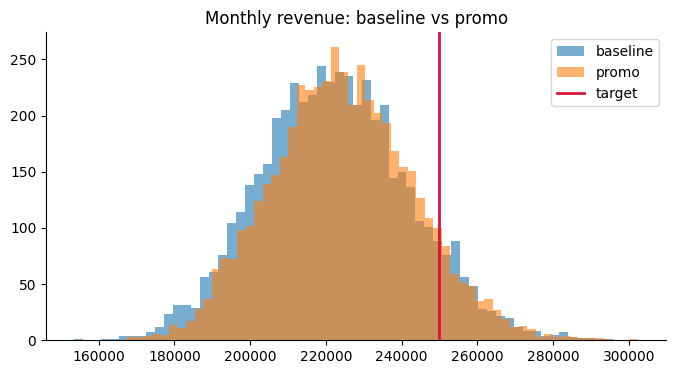

In [11]:
plt.hist(base, bins=60, alpha=0.6, label="baseline")
plt.hist(promo, bins=60, alpha=0.6, label="promo")
plt.axvline(target, color="crimson", lw=2, label="target")
plt.legend(); plt.title("Monthly revenue: baseline vs promo"); plt.show()

Revenue goes up only ~1% (1.10 × 0.92 ≈ 1.012), well within month-to-month noise. P(hitting target) barely moves.

**Recommendation: probably not worth it on revenue alone.** 10% more orders means more fulfillment and shipping cost, so *profit* likely drops. The promo only makes sense for a different goal, like acquiring new customers who come back later (lifetime value).
Good answers here state the assumption they're making about costs.

### A4. Bootstrap CI for the 90th percentile

In [12]:
sample = rng.choice(population, size=60)

def boot_ci(data, stat, n_boot=10_000):
    boots = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(n_boot)])
    return np.percentile(boots, [2.5, 97.5]), boots

(med_lo, med_hi), _ = boot_ci(sample, np.median)
p90 = lambda x: np.percentile(x, 90)
(p90_lo, p90_hi), boots90 = boot_ci(sample, p90)

print(f"Median:          {np.median(sample):7.2f}   95% CI {med_lo:7.2f} to {med_hi:7.2f}   width {med_hi - med_lo:6.2f}")
print(f"90th percentile: {p90(sample):7.2f}   95% CI {p90_lo:7.2f} to {p90_hi:7.2f}   width {p90_hi - p90_lo:6.2f}")

Median:            34.62   95% CI   26.62 to   42.81   width  16.18
90th percentile:   90.57   95% CI   70.41 to  123.47   width  53.06


The 90th-percentile interval is much wider because it's estimated from **very few data points**. With 60 customers only ~6 are above the 90th percentile, and in the right tail of a skewed distribution those values are spread far apart.
Each bootstrap resample can include or drop one of those big spenders, which swings the estimate a lot.
Takeaway: **estimating tails (top spenders, worst-case wait times) needs far more data than estimating the middle.**